  3%|▎         | 113/4000 [00:00<00:06, 600.03it/s]

262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262
262


 14%|█▎        | 540/4000 [00:00<00:03, 1007.96it/s]

264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264
264


 24%|██▍       | 959/4000 [00:01<00:03, 959.84it/s] 

...

 93%|█████████▎| 3739/4000 [00:04<00:00, 917.88it/s] 

None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None


100%|██████████| 4000/4000 [00:04<00:00, 917.05it/s]


Ommatidia readouts This browser does not support the video tag.


(512, 900, 3)
<class 'list'>
[222 210 181] 0
[220 208 179] 1
[220 208 179] 2
[220 208 179] 3
[217 204 177] 4
[217 204 177] 5
[107 165  87] 6
[107 165  87] 7
[  0 128   0] 8
[  0 128   0] 9


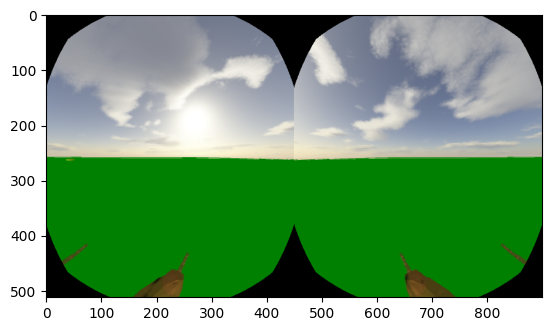

In [22]:
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

import numpy as np
import matplotlib.pyplot as plt
import mediapy
can_walk = False

def detects_horizon_while_stopped(screenshot):
    can_walk = False

    #height_of_horizon = 0
    for i in range(5):
        if screenshot[260+i, 100][1] == 128:
            height_of_horizon = 261+i
            can_walk = True
            return height_of_horizon
    

sim = MiniprojectSimulation(level=0, seed=42)
controller = Controller(sim)
frames = []

for k in trange(4000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)

    if k>2000 & k%400==0:
        temp = detects_horizon_while_stopped(frames[-1])
        print(temp)
    else:
        sim.step()

    if sim.render_as_needed():
        ommatidia_readouts = sim.get_ommatidia_readouts(sim.fly.name)
        im = np.concatenate(
            [
                sim.get_raw_vision(sim.fly.name)[0],
                sim.get_raw_vision(sim.fly.name)[1]
                
            ], axis=1
        )
        frames.append(im)

mediapy.show_video(frames, fps=sim.renderer.output_fps, title="Ommatidia readouts")
#sim.renderer.show_in_notebook()


###########################################################
#################### TEST ADRI ############################
###########################################################

############### debugg
plt.imshow(frames[0])
print(frames[0].shape)
print(type(frames))
for i in range(10):
    print(frames[20][255+i, 100], i)
############### debugg


